In [1]:
from google.colab import drive
drive.mount('/content/drive')

import sys
sys.path.append('/content/drive/MyDrive/Prime_NN')

Mounted at /content/drive


In [2]:
import torch

if torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using CUDA GPU:", torch.cuda.get_device_name(0))

elif torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using Apple MPS")

else:
    device = torch.device("cpu")
    print("Using CPU")

import torch.nn as nn
from dataset import PrimeDataset
from models import PrimeTransformer
from torch.utils.data import DataLoader, random_split

torch.manual_seed(42)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_auc_score, roc_curve
import time
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt


from pathlib import Path

BASE_DIR = Path("/content/drive/MyDrive/Prime_NN")

DATA_PATH = BASE_DIR / "train_dataset.csv"
M_R_DIR = BASE_DIR / "models_results/transformer_binary_only"

Using CUDA GPU: Tesla T4


In [3]:
dataset = PrimeDataset(DATA_PATH, mode= "binary", model_type= "transformer")

print("Dataset size:", len(dataset))

input_length = dataset.input_dim
print("Input length:", input_length)

Dataset size: 749999
Input length: 21


In [4]:
train_size = int(0.85 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = random_split(
    dataset,
    [train_size, test_size],
    generator=torch.Generator().manual_seed(42))


bs = 256

train_loader = DataLoader(train_dataset, batch_size=bs, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=bs, shuffle=False)

In [5]:
model = PrimeTransformer(input_length).to(device)

train_labels = dataset.labels[train_dataset.indices]
train_labels = torch.tensor(train_labels)

num_pos = train_labels.sum().item()
num_neg = len(train_labels) - num_pos

pos_weight = torch.tensor([num_neg / (num_pos + 1e-8)]).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.0003,
    weight_decay=1e-5
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=3
)

epochs = 100

early_stop_patience = 7
epochs_without_improve = 0
best_val_loss = float("inf")

/content/drive/MyDrive/Prime_NN/models.py:102: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers)


In [6]:
train_losses = []
val_losses = []

for epoch in range(epochs):

    start_time = time.time()

    model.train()
    train_loss = 0

    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")

    for x, y in progress_bar:

        x = x.to(device)
        y = y.to(device).float()

        optimizer.zero_grad()

        outputs = model(x)

        loss = criterion(outputs, y)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()

        train_loss += loss.item()

        progress_bar.set_postfix(loss=loss.item())

    train_loss /= len(train_loader)

    model.eval()
    val_loss = 0

    with torch.no_grad():

        for x, y in test_loader:

            x = x.to(device)
            y = y.to(device).float()

            outputs = model(x)

            loss = criterion(outputs, y)

            val_loss += loss.item()

    val_loss /= len(test_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    scheduler.step(val_loss)

    current_lr = optimizer.param_groups[0]['lr']

    epoch_time = time.time() - start_time

    print(
        f"Epoch {epoch+1}/{epochs} | "
        f"LR: {current_lr:.6f} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Time: {epoch_time:.2f}s"
    )

    if val_loss < best_val_loss - 1e-4:

        best_val_loss = val_loss
        epochs_without_improve = 0

        torch.save({
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "input_length": input_length,
            "use_mods": False,
            "epoch": epoch,
            "val_loss": val_loss
            }, M_R_DIR / "transformer_binary_only.pt")

    else:

        epochs_without_improve += 1

    if epochs_without_improve >= early_stop_patience:

        print("\nEarly stopping triggered.")
        print(f"No improvement for {early_stop_patience} epochs.")

        break

Epoch 1/100: 100%|██████████| 2491/2491 [00:48<00:00, 51.21it/s, loss=0.849]


Epoch 1/100 | LR: 0.000300 | Train Loss: 0.8857 | Val Loss: 0.8298 | Time: 52.08s


Epoch 2/100: 100%|██████████| 2491/2491 [00:48<00:00, 51.03it/s, loss=0.782]


Epoch 2/100 | LR: 0.000300 | Train Loss: 0.8336 | Val Loss: 0.8303 | Time: 51.37s


Epoch 3/100: 100%|██████████| 2491/2491 [00:48<00:00, 50.92it/s, loss=0.676]


...

Epoch 11/100 | LR: 0.000150 | Train Loss: 0.8315 | Val Loss: 0.8290 | Time: 50.25s


Epoch 12/100: 100%|██████████| 2491/2491 [00:48<00:00, 51.21it/s, loss=0.654]


Epoch 12/100 | LR: 0.000150 | Train Loss: 0.8314 | Val Loss: 0.8292 | Time: 51.36s


Epoch 13/100: 100%|██████████| 2491/2491 [00:48<00:00, 51.85it/s, loss=0.738]


Epoch 13/100 | LR: 0.000150 | Train Loss: 0.8314 | Val Loss: 0.8297 | Time: 51.35s

Early stopping triggered.
No improvement for 7 epochs.


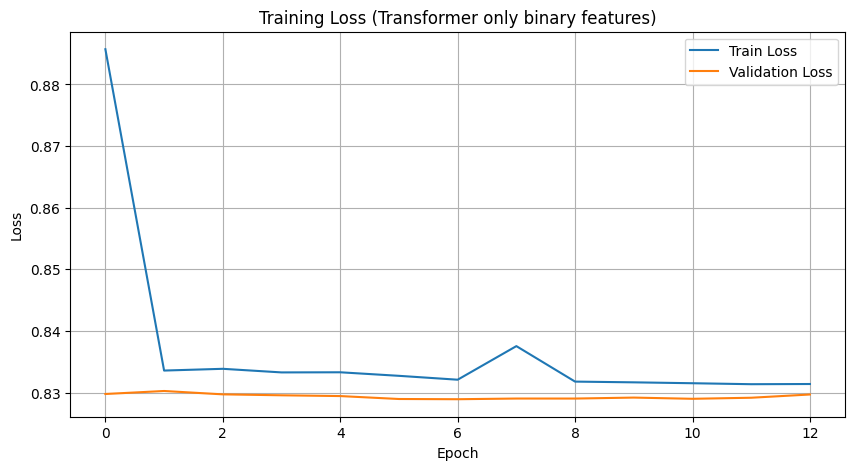

In [7]:
plt.figure(figsize=(10,5))

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss (Transformer only binary features)")

plt.legend()
plt.grid()
plt.savefig(M_R_DIR / "loss_curve.png")
plt.show()

In [8]:
model.eval()

all_probs = []
all_labels = []

with torch.no_grad():
    for x, y in test_loader:

        x = x.to(device)
        y = y.to(device).float()

        outputs = model(x)
        probs = torch.sigmoid(outputs)

        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

all_probs = np.array(all_probs)
all_labels = np.array(all_labels)

thresholds = np.linspace(0.01, 0.99, 200)
f1_scores = []

for t in thresholds:
    preds = (all_probs > t).astype(int)
    f1_scores.append(f1_score(all_labels, preds))

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print("Best threshold:", best_threshold)
print("Best F1:", f1_scores[best_idx])

Best threshold: 0.6748241206030151
Best F1: 0.27387392910236175


In [9]:
all_preds = (all_probs > best_threshold).astype(int)

accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, zero_division=0)
recall = recall_score(all_labels, all_preds, zero_division=0)
f1 = f1_score(all_labels, all_preds, zero_division=0)
auc = roc_auc_score(all_labels, all_probs)

false_primes = np.sum((all_preds == 1) & (all_labels == 0))

print("Threshold:", best_threshold)
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("ROC AUC  :", auc)
print("False primes:", false_primes)

Threshold: 0.6748241206030151
Accuracy : 0.5788533333333333
Precision: 0.15866392016194908
Recall   : 1.0
F1 Score : 0.27387392910236175
ROC AUC  : 0.7805788616244969
False primes: 47379


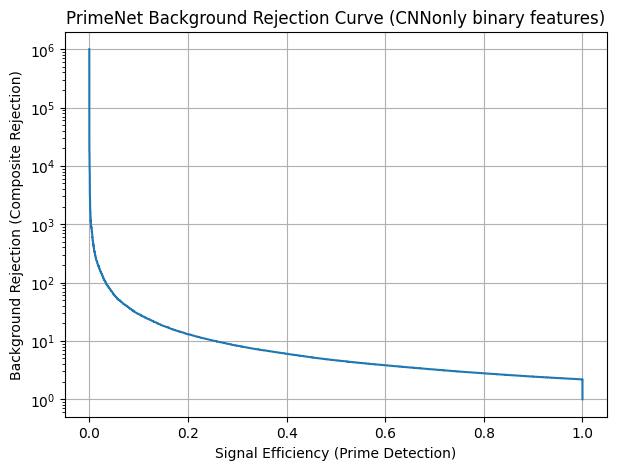

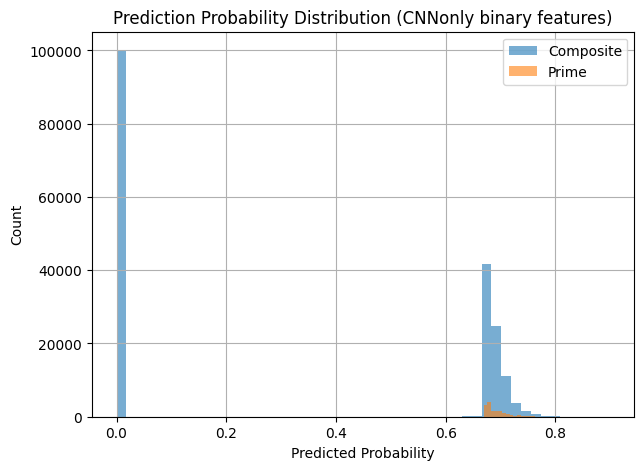

In [ ]:
fpr, tpr, thresholds = roc_curve(all_labels, all_probs)

fpr_safe = np.clip(fpr, 1e-6, None)

background_rejection = 1 / fpr_safe
signal_efficiency = tpr

order = np.argsort(signal_efficiency)
signal_efficiency = signal_efficiency[order]
background_rejection = background_rejection[order]

plt.figure(figsize=(7,5))

plt.plot(signal_efficiency, background_rejection)

plt.xlabel("Signal Efficiency (Prime Detection)")
plt.ylabel("Background Rejection (Composite Rejection)")
plt.title("Background Rejection Curve (Transformer only binary features)")

plt.yscale("log")
plt.grid(True)
plt.savefig(M_R_DIR / "background_rejection_curve.png")
plt.show()

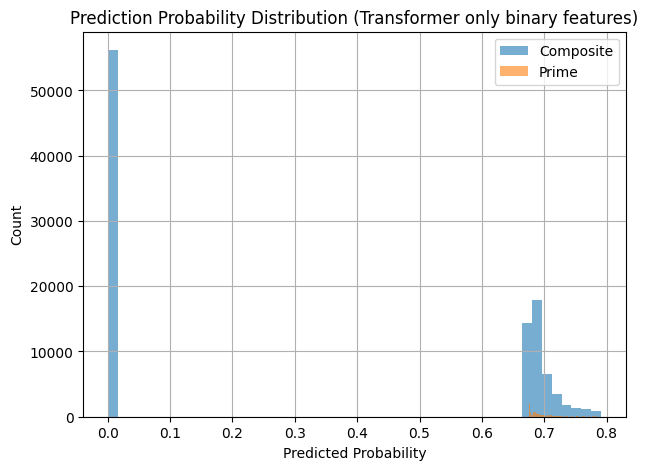

In [10]:
prime_probs = [p for p, l in zip(all_probs, all_labels) if l == 1]
comp_probs  = [p for p, l in zip(all_probs, all_labels) if l == 0]

plt.figure(figsize=(7,5))

plt.hist(comp_probs, bins=50, alpha=0.6, label="Composite")
plt.hist(prime_probs, bins=50, alpha=0.6, label="Prime")

plt.xlabel("Predicted Probability")
plt.ylabel("Count")
plt.title("Prediction Probability Distribution (Transformer only binary features)")

plt.legend()
plt.grid(True)
plt.savefig(M_R_DIR / "probability_distribution.png")
plt.show()